,model,h,RMSE,MAE,LB_pvalue_lag48,RMSE_persistence,Skill_vs_persistence
0,RLS_ARX,1,1.502568,0.970101,8.131898e-09,1.653773,0.091430
1,Kalman_White,1,1.508938,0.971887,4.647837e-13,1.653773,0.087578
2,Kalman_AR1Noise,1,1.532059,0.987339,1.221016e-09,1.653773,0.073598
3,Kalman_AR1Noise,2,1.597877,1.051620,1.770696e-88,2.492154,0.358837
4,Kalman_White,2,1.856969,1.240923,0.000000e+00,2.492154,0.254874
5,RLS_ARX,2,1.962508,1.306722,0.000000e+00,2.492154,0.212525
6,Kalman_AR1Noise,3,1.606318,1.060348,5.286675e-103,3.086808,0.479618
7,Kalman_White,3,1.900961,1.280913,0.000000e+00,3.086808,0.384166
8,RLS_ARX,3,2.110918,1.430796,0.000000e+00,3.086808,0.316149


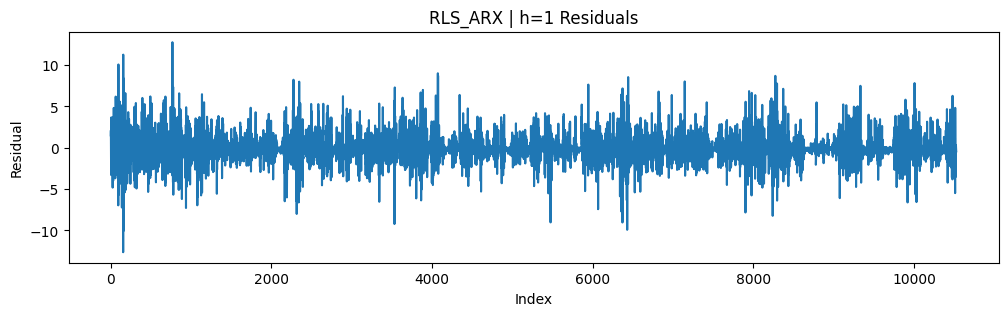

<Figure size 640x480 with 0 Axes>

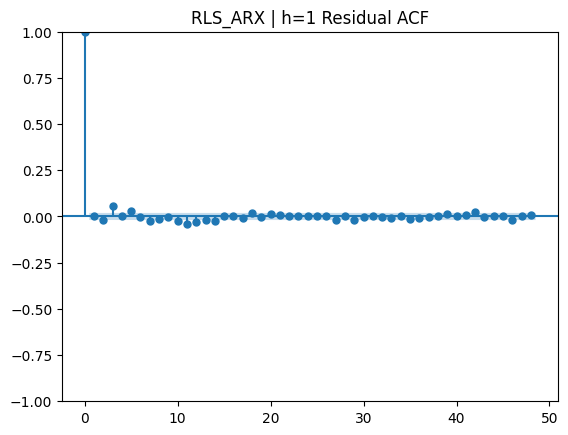

<Figure size 640x480 with 0 Axes>

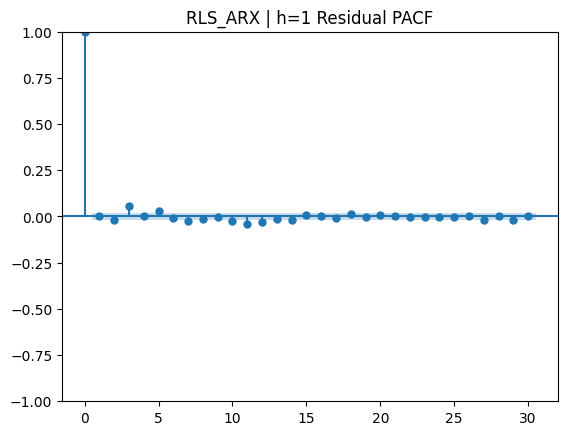

       lb_stat     lb_pvalue
12   83.891185  7.432512e-13
24   98.699337  5.002227e-11
48  125.233637  8.131898e-09


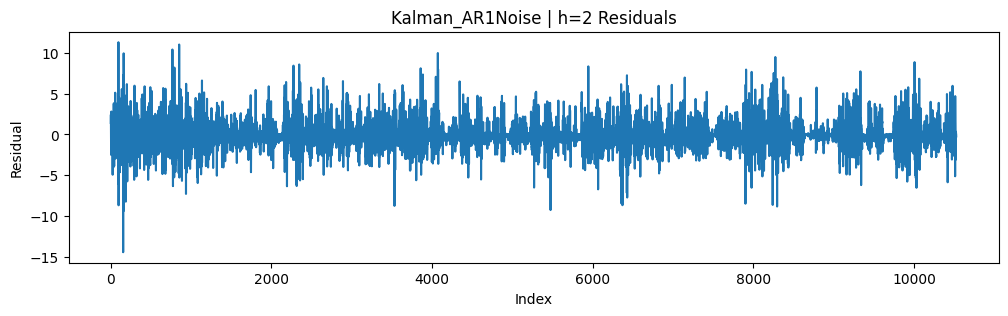

<Figure size 640x480 with 0 Axes>

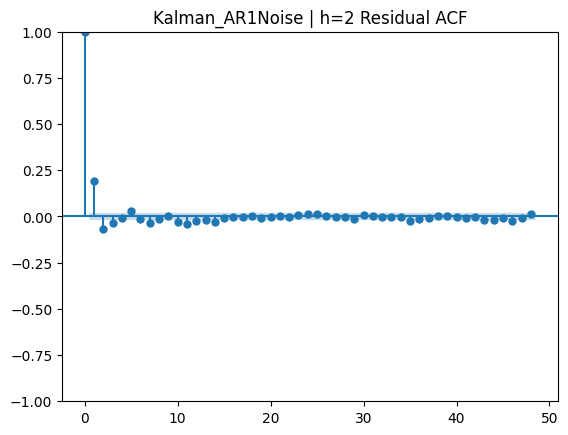

<Figure size 640x480 with 0 Axes>

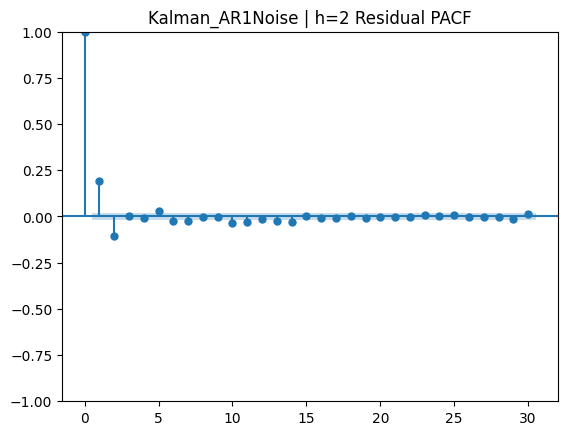

       lb_stat      lb_pvalue
12  511.128517  9.478047e-102
24  528.626952   1.864918e-96
48  560.293988   1.770696e-88


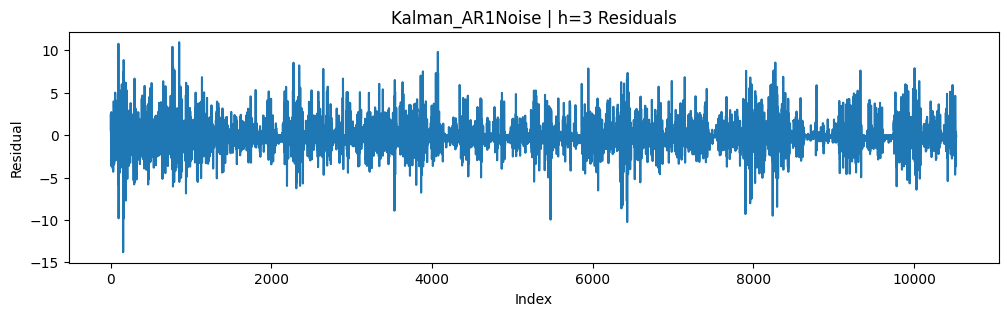

<Figure size 640x480 with 0 Axes>

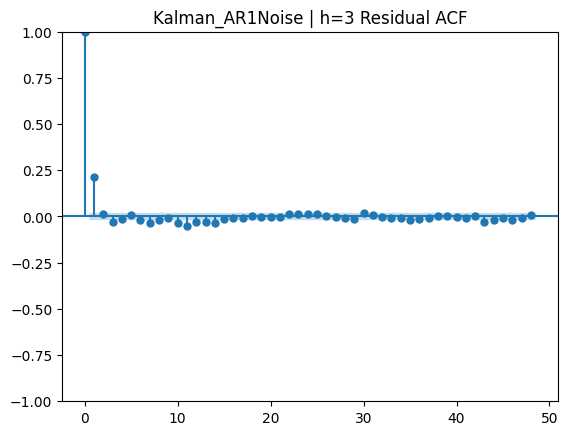

<Figure size 640x480 with 0 Axes>

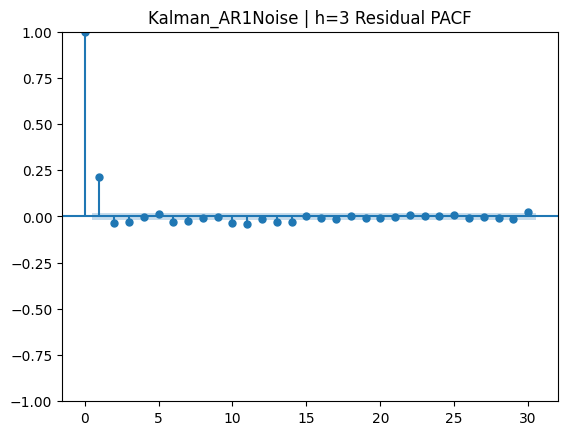

       lb_stat      lb_pvalue
12  561.657598  1.615857e-112
24  592.893679  7.267685e-110
48  632.758538  5.286675e-103


In [1]:
from models import (WindDataManager, RLS_ARX_Model,
                    Kalman_White_ARX_Model, Kalman_AR1_Noise_Model, ComparisonRunner)
data_mgr = WindDataManager(
    data_path=r"../data/cex4WindDataInterpolated.csv",  # <-- adjust
    max_lag=200,
    train_frac=0.7,
    val_frac_within_train=0.2,
)
data_mgr.load_and_prepare()

# 2) Models (separated, no duplicated preprocessing)
models = {
    "RLS_ARX": RLS_ARX_Model(tarso_h1=True),
    "Kalman_White": Kalman_White_ARX_Model(tarso_h1=True),
    "Kalman_AR1Noise": Kalman_AR1_Noise_Model(phi=0.6, q_beta=1e-5, r_eps=0.5),  # tweak these
}

# 3) Run comparison
runner = ComparisonRunner(data_mgr, lb_lag=48)
results_df, traces = runner.run(models, horizons=[1, 2, 3])
display(results_df)

# 4) Residual analysis (same call style for all models)
#    Example: show residual plots for the best model per horizon
for h in [1, 2, 3]:
    best_row = results_df[results_df["h"] == h].sort_values("RMSE").iloc[0]
    m = best_row["model"]
    resid = traces[m][h]["resid"]
    runner.residual_plots(resid, title_prefix=f"{m} | h={h}", lags=48)
